---
title: More on Sinusoidal Models
---

### Sunspots Dataset

In [87]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

To this sunspots dataset, we shall fit the sinusoidal model: 
\begin{equation*}
  y_t = \beta_0 + \beta_1 \cos(2 \pi f t) + \beta_2 \sin(2 \pi f t) + \epsilon_t
\end{equation*}
with $\epsilon_t$ being i.i.d $N(0, \sigma^2)$. We focus on estimation and uncertainty quantification for the important parameter in this model is $f$. We do this in two ways: (a) using Fourier frequencies, and (b) using a dense grid of frequencies, and we compare the results. 

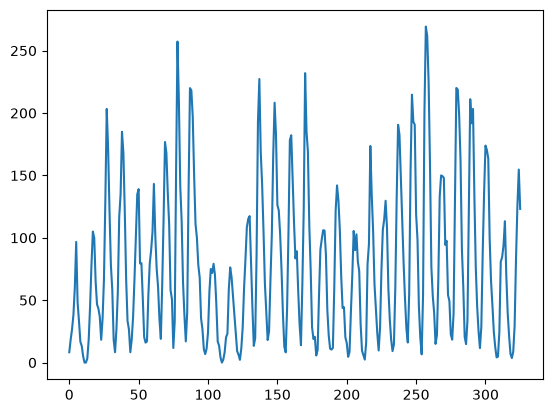

In [88]:
sunspots = pd.read_csv('SN_y_tot_V2.0_17Sept2026.csv', header = None, sep = ';')
y = sunspots.iloc[:,1].values
n = len(y)
plt.plot(y)
plt.show()

When restricting to Fourier frequencies, computation of $RSS(f)$ proceeds via the DFT and periodogram. Here is the code for computing the periodogram.

In [89]:
def periodogram(y):
    fft_y = np.fft.fft(y) #this computation is very fast O(n log n)
    n = len(y)
    fourier_freqs = np.arange(1/n, 1/2, 1/n)
    m = len(fourier_freqs)
    pgram_y = (np.abs(fft_y[1:m+1]) ** 2)/n
    return fourier_freqs, pgram_y


Below we plot the periodogram. 

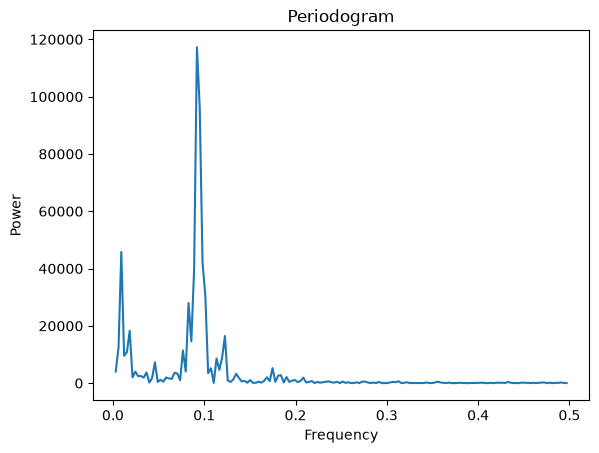

In [90]:
freqs, pgram = periodogram(y)
plt.plot(freqs, pgram)
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

Below is the code for computing the RSS using the periodogram.

In [91]:
def rss_periodogram(y):
    fft_y = np.fft.fft(y)
    n = len(y)
    fourier_freqs = np.arange(1/n, 1/2, 1/n)
    m = len(fourier_freqs)
    pgram_y = (np.abs(fft_y[1:m+1]) ** 2)/n
    var_y = np.sum((y - np.mean(y)) ** 2)
    rssvals = var_y - 2*pgram_y
    return fourier_freqs, rssvals

The following is the plot for the RSS (restricted to Fourier frequencies in the range $(0, 0.5)$):

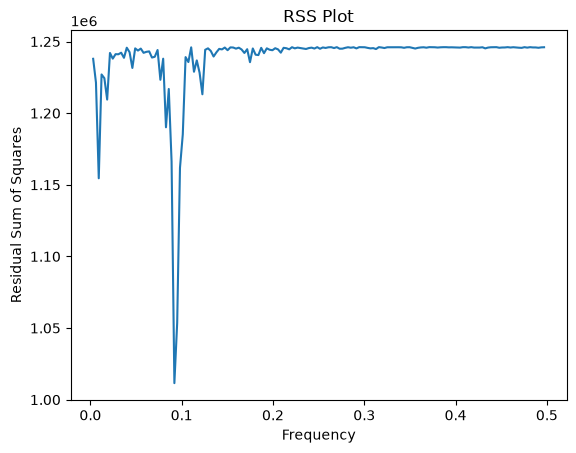

In [92]:
freqs, rssvals = rss_periodogram(y)
plt.plot(freqs, rssvals)
plt.xlabel('Frequency')
plt.ylabel('Residual Sum of Squares')
plt.title('RSS Plot')
plt.show()

Below is the estimate of $f$ (along with the corresponding period) based on this RSS. It is simply the minimizer of RSS (or equivalently, maximizer of the periodogram):

In [93]:
#Estimate of f and the corresponding period: 
fhat = freqs[np.argmax(pgram)]
print(fhat)
period_hat = 1/fhat
print(period_hat)

0.09202453987730061
10.866666666666667


The estimate of the period is somewhat close to 11 but not very close. Let us now do uncertainty quantification (again with the restriction to Fourier frequencies) to see how wide the uncertainty interval for $f$ is. The following function calculates the posterior for $f$ on the log-scale. Recall that the posterior is given by: 
\begin{align*}
  \text{posterior}(j/n) \propto \left(\frac{1}{RSS(j/n)} \right)^{(n-3)/2} I\{0 < j/n < 0.5\}.
\end{align*}
Note that there is no term $|X_f^T X_f|^{-1/2}$ as this term is a constant (not depending on $f$) when $f$ is restricted to Fourier frequencies. In the function below, we compute this posterior on the log-scale, and we use the connection between RSS and periodogram to compute the RSS. 

In [94]:
#Uncertainty quantification for f: 
def logpost_periodogram(y):
    fft_y = np.fft.fft(y)
    n = len(y)
    fourier_freqs = np.arange(1/n, (1/2) + (1/n), 1/n)
    m = len(fourier_freqs)
    pgram_y = (np.abs(fft_y[1:m+1]) ** 2)/n
    var_y = np.sum((y - np.mean(y)) ** 2)
    rssvals = var_y - 2*pgram_y
    p = 3
    logpostvals = ((p-n)/2) * np.log(rssvals)
    return fourier_freqs, logpostvals

Below we plot the log posterior as a function of the fourier frequencies. 

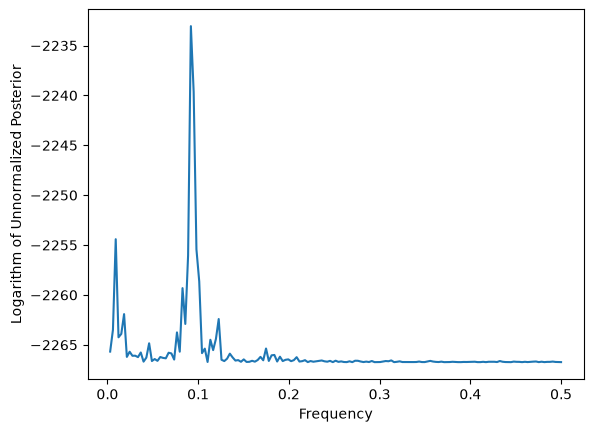

In [95]:
freqs, logpostvals = logpost_periodogram(y)
plt.plot(freqs, logpostvals)
plt.xlabel('Frequency')
plt.ylabel('Logarithm of Unnormalized Posterior')
plt.show()

Below we exponentiate the log-posterior to compute the posterior (and subsequently normalize the posterior). We then compute the posterior mode, and the smallest symmetric region around the posterior mode for which the posterior probability exceeds 0.95. This will give our uncertainty interval for $f$. Note again that in this analysis, we are restricting $f$ to the set of Fourier frequencies. 

In [96]:
freqs, logpostvals = logpost_periodogram(y)
postvals_unnormalized = np.exp(logpostvals - np.max(logpostvals))
postvals = postvals_unnormalized/(np.sum(postvals_unnormalized))

def PostProbAroundMax(m):
    est_ind = np.argmax(postvals)
    ans = np.sum(postvals[(est_ind-m):(est_ind+m+1)])
    return(ans)
m = 0
while PostProbAroundMax(m) <= 0.95:
    m = m+1
est_ind = np.argmax(postvals)
f_est = freqs[est_ind]
#95% credible interval for f:
ci_f_low = freqs[est_ind - m]
ci_f_high = freqs[est_ind + m]
print(np.array([f_est, ci_f_low, ci_f_high]))

period_est = 1/f_est
ci_period_low = 1/ci_f_high
ci_period_high = 1/ci_f_low
print(np.array([ci_period_low, period_est, ci_period_high]))


[0.09202454 0.09202454 0.09202454]
[10.86666667 10.86666667 10.86666667]


See that these uncertainty intervals (credible intervals) are just comprised of the single point given by the least squares estimators. This is because the grid is too coarse. At the least squares estimate $\hat{f}$, the posterior probability is much higher than every other frequency in the grid including the nearby frequencies $\hat{f} \pm 1/n$. This is because the RSS at $\hat{f}$ is much lower compared to the RSS at every other frequency, as shown below.

In [97]:
def rss(f):
    n = len(y)
    x = np.arange(1, n + 1)
    xcos = np.cos(2 * np.pi * f * x)
    xsin = np.sin(2 * np.pi * f * x)
    X = np.column_stack([np.ones(n), xcos, xsin])
    md = sm.OLS(y, X).fit()
    return np.sum(md.resid**2)

print(rss(f_est + 1/n) -rss(f_est))
print(rss(f_est - 1/n) -rss(f_est))

42062.71407990053
154676.63515544275


To get a better estimate of the frequency, as well as a meaningful uncertainty interval, we need to work with a much finer (i.e., more dense) grid. 

In [98]:
def logpost(f):
    n = len(y)
    x = np.arange(1, n+1)
    xcos = np.cos(2 * np.pi * f * x)
    xsin = np.sin(2 * np.pi * f * x)
    X = np.column_stack([np.ones(n), xcos, xsin])
    p = X.shape[1]
    md = sm.OLS(y, X).fit()
    rss = np.sum(md.resid ** 2)
    sgn, log_det = np.linalg.slogdet(np.dot(X.T, X)) #sgn gives the sign of the determinant (in our case, this should 1)
    #log_det gives the logarithm of the absolute value of the determinant
    logval = ((p-n)/2) * np.log(rss) - (0.5)*log_det
    return logval

allfvals = np.arange(0.01, 0.5, .00001) #much finer grid
logpostvals = np.array([logpost(f) for f in allfvals])
postvals = np.exp(logpostvals - np.max(logpostvals))
postvals = postvals/(np.sum(postvals))
print(allfvals[np.argmax(postvals)])
print(1/allfvals[np.argmax(postvals)])


0.09088999999999671
11.00231048520229


In [99]:
def PostProbAroundMax(m):
    est_ind = np.argmax(postvals)
    ans = np.sum(postvals[(est_ind-m):(est_ind+m+1)])
    return(ans)
m = 0
while PostProbAroundMax(m) <= 0.95:
    m = m+1
est_ind = np.argmax(postvals)
f_est = allfvals[est_ind]
#95% credible interval for f:
ci_f_low = allfvals[est_ind - m]
ci_f_high = allfvals[est_ind + m]
print(np.array([f_est, ci_f_low, ci_f_high]))

period_est = 1/f_est
ci_period_low = 1/ci_f_high
ci_period_high = 1/ci_f_low
print(np.array([ci_period_low, period_est, ci_period_high]))

[0.09089 0.09061 0.09117]
[10.96852035 11.00231049 11.03630946]


Now the frequency estimate basically corresponds to the time period of 11 years. Also, now the interval is not concentrated at a single point. For a clearer interpretation of the uncertainty interval, let us convert the uncertainty in the units of days. 

In [100]:
np.array([(period_est - ci_period_low)*365, (ci_period_high - period_est)*365])

array([12.33340059, 12.40962511])

So the uncertainty period can be summarized as:
\begin{equation*}
   [11 \text{ years } - 12.33 \text{ days}, 11 \text{ years } + 12.41 \text{ days}].
\end{equation*}
This interval is quite narrow which can be seen as a feature of the single sinusoid model. Also note that this interval for the period ($1/f$) is not symmetric because we took inverses (the interval for $f$ is symmetric). 

## Orthogonality of Sinusoids at Fourier Frequencies

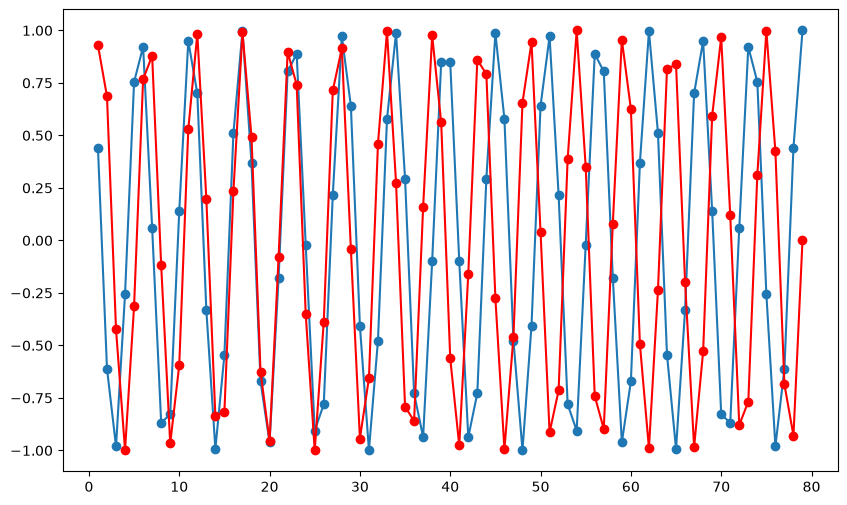

-6.72705371516124e-15


In [107]:
n = 79
t = np.arange(1, n+1)
f1 = 14/n
f2 = 15/n
cos_f1 = np.cos(2 * np.pi * f1 * t)
sin_f1 = np.sin(2 * np.pi * f1 * t)
cos_f2 = np.cos(2 * np.pi * f2 * t)
sin_f2 = np.sin(2 * np.pi * f2 * t)
plt.figure(figsize = (10, 6))
y1 = cos_f1
y2 = sin_f2
plt.plot(t, y1, '-o')
plt.plot(t, y2, '-o', color = 'red')
plt.show()
print(sum(y1 * y2)) #should equal zero if f1 and f2 are distinct Fourier frequencies

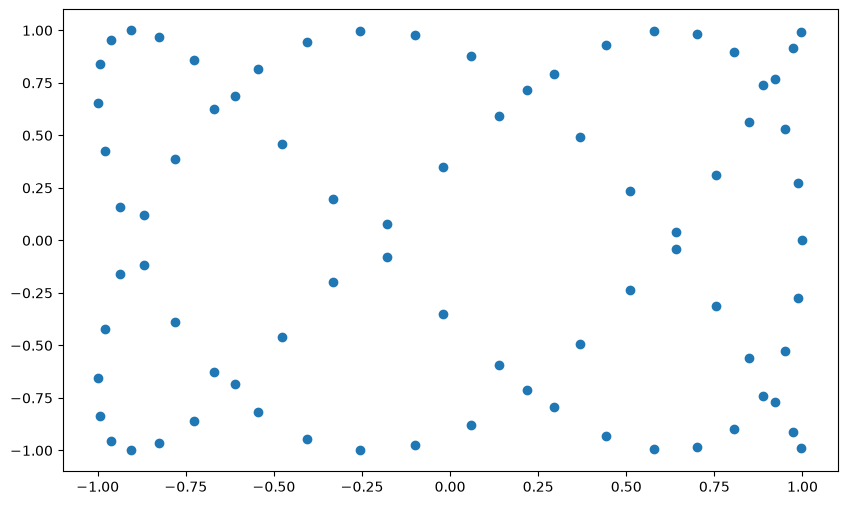

In [108]:
plt.figure(figsize = (10, 6))
plt.scatter(y1, y2) #if f1 and f2 are distinct Fourier frequencies, there should be no linear trend in this scatter plot
plt.show()

## Fitting more sinusoids to the sunspots data

We now consider the model with two sinusoids: 
\begin{equation*}
  y_t = \beta_0 + \beta_1 \cos(2 \pi f_1 t) + \beta_2 \sin(2 \pi f_1 t) + \beta_3 \cos(2 \pi f_2 t) + \beta_4 \sin(2 \pi f_2 t) + \epsilon_t
\end{equation*}
with both $f_1$ and $f_2$ denoting unknown parameters (along with $\beta_0, \beta_1, \beta_2, \beta_3, \beta_4$ and $\sigma$).

Before fitting this model to the data, let us first compute the fitted values for the best single sinusoidal model (that we fit above). 

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     70.86
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           3.06e-26
Time:                        19:40:18   Log-Likelihood:                -1747.8
No. Observations:                 326   AIC:                             3502.
Df Residuals:                     323   BIC:                             3513.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         78.8656      2.868     27.496      0.0

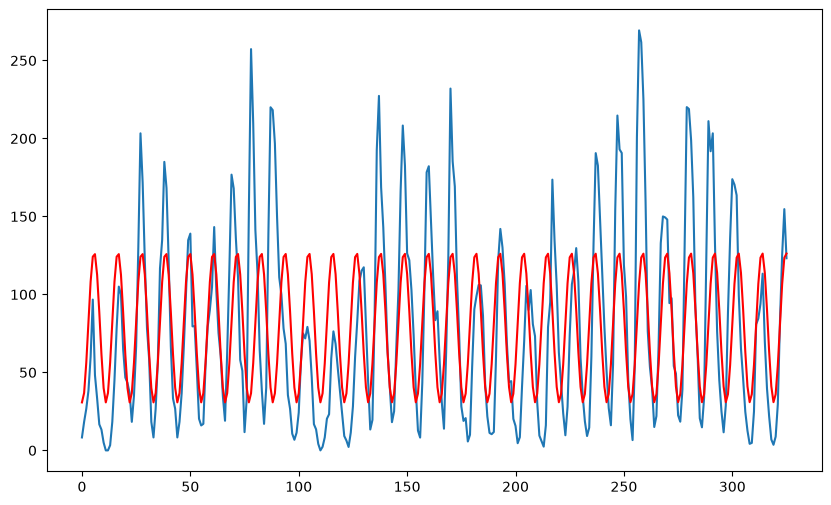

In [109]:
n = len(y)
f = f_est
x = np.arange(1, n+1)
X = np.column_stack([np.ones(n)])
x = np.arange(1, n+1)
if np.isscalar(f):
    f = [f]
for j in range(len(f)):
    f1 = f[j]
    xcos = np.cos(2 * np.pi * f1 * x)
    xsin = np.sin(2 * np.pi * f1 * x)
    X = np.column_stack([X, xcos, xsin])

md_1 = sm.OLS(y, X).fit()
print(md_1.summary())
best_rss_1 = np.sum(md_1.resid ** 2)
print(best_rss_1)

plt.figure(figsize = (10, 6))
#plt.plot(y, linestyle = '', marker = '')
plt.plot(y)
#plt.plot(md1.fittedvalues, color = 'red', marker = '', linestyle = '')
#plt.plot(md2.fittedvalues, color = 'black', marker = '', linestyle = '')
plt.plot(md_1.fittedvalues, color = 'red')
plt.show()

Below we write a function for calculating RSS with multiple frequencies. 

In [110]:
def rss(f):
    n = len(y)
    X = np.column_stack([np.ones(n)])
    x = np.arange(1, n+1)
    if np.isscalar(f):
        f = [f]
    for j in range(len(f)):
        f1 = f[j]
        xcos = np.cos(2 * np.pi * f1 * x)
        xsin = np.sin(2 * np.pi * f1 * x)
        X = np.column_stack([X, xcos, xsin])
    md = sm.OLS(y, X).fit()
    ans = np.sum(md.resid ** 2)
    return ans


In the code below, we search over two frequencies $f_1$ and $f_2$ which best fit to the data. For the range of frequencies, we restrict to the range $(0, 0.15)$. This is because it seems unlikely that sinusoids with frequencies larger than 0.15 will fit well to the data. 

In [111]:
f1_gr = np.linspace(0, 0.15, 1000)
f2_gr = np.linspace(0, 0.15, 1000)
X, Y = np.meshgrid(f1_gr, f2_gr, indexing='ij')
mask = (X <= Y)
xf, yf = X[mask], Y[mask]
def _rssk(x, y):
    return rss([float(x), float(y)])
rss_vec = np.vectorize(_rssk)   
rss_vals = rss_vec(xf, yf)
g = pd.DataFrame({'x': xf, 'y': yf, 'rss': rss_vals})

In [112]:
min_row = g.loc[g['rss'].idxmin()]
print(min_row)
f_opt_2 = np.array([min_row['x'], min_row['y']])
print(f_opt_2)
print(1/f_opt_2)

x           0.090691
y           0.099850
rss    702659.814908
Name: 421955, dtype: float64
[0.09069069 0.09984985]
[11.02649007 10.01503759]


Below we plot the fitted function with the two best frequencies obtained as above. 

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     62.06
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           8.28e-39
Time:                        19:43:40   Log-Likelihood:                -1713.7
No. Observations:                 326   AIC:                             3437.
Df Residuals:                     321   BIC:                             3456.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         79.0717      2.592     30.508      0.0

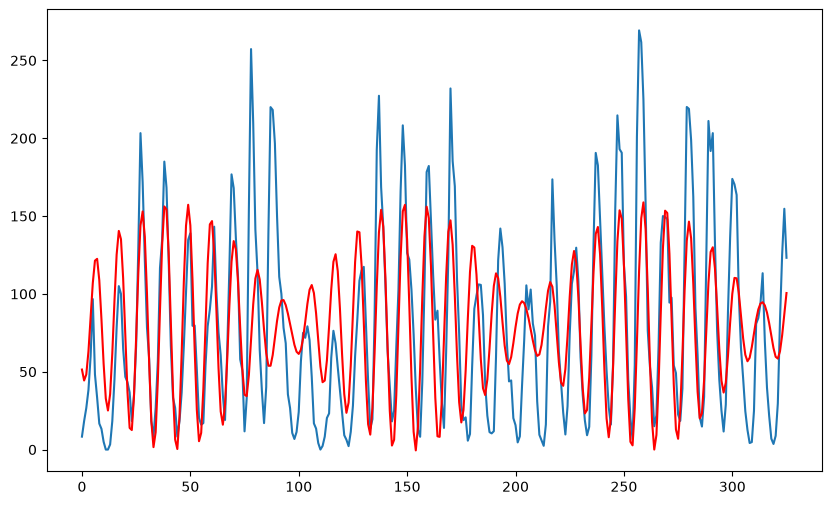

In [113]:
n = len(y)
f = f_opt_2 #f_opt was obtained from the grid minimization
x = np.arange(1, n+1)
X = np.column_stack([np.ones(n)])
x = np.arange(1, n+1)
if np.isscalar(f):
    f = [f]
for j in range(len(f)):
    f1 = f[j]
    xcos = np.cos(2 * np.pi * f1 * x)
    xsin = np.sin(2 * np.pi * f1 * x)
    X = np.column_stack([X, xcos, xsin])

md_2 = sm.OLS(y, X).fit()
print(md_2.summary())
best_rss_2 = np.sum(md_2.resid ** 2)
print(best_rss_2)


plt.figure(figsize = (10, 6))
#plt.plot(y, linestyle = '', marker = '')
plt.plot(y)
#plt.plot(md_1.fittedvalues, color = 'black')
#plt.plot(md2.fittedvalues, color = 'black', marker = '', linestyle = '')
plt.plot(md_2.fittedvalues, color = 'red')
plt.show()

Next we try to find the three best frequencies, again using a grid minimization strategy. 

In [114]:
f1_gr = np.linspace(0, 0.15, 200)
f2_gr = np.linspace(0, 0.15, 200)
f3_gr = np.linspace(0, 0.15, 200)
# mesh on the 3 axes; 'ij' preserves axis ordering
X, Y, Z = np.meshgrid(f1_gr, f2_gr, f3_gr, indexing='ij')
# keep only nondecreasing triples to kill permutations:
mask = (X <= Y) & (Y <= Z)
xf, yf, zf = X[mask], Y[mask], Z[mask]
def _rss3(x, y, z):
    return rss([float(x), float(y), float(z)])
rss_vec = np.vectorize(_rss3)   
rss_vals = rss_vec(xf, yf, zf)
g = pd.DataFrame({'x': xf, 'y': yf, 'z': zf, 'rss': rss_vals})

In [115]:
min_row = g.loc[g['rss'].idxmin()]
print(min_row)
f_opt_3 = np.array([min_row['x'], min_row['y'], min_row['z']])
print(f_opt_3)
print(1/f_opt_3)

x           0.091206
y           0.093467
z           0.100251
rss    580371.712625
Name: 1268323, dtype: float64
[0.09120603 0.09346734 0.10025126]
[10.96418733 10.69892473  9.97493734]


Next we plot the fitted function using the three best frequencies.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     60.99
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           4.40e-50
Time:                        19:47:16   Log-Likelihood:                -1682.6
No. Observations:                 326   AIC:                             3379.
Df Residuals:                     319   BIC:                             3406.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         78.7271      2.363     33.315      0.0

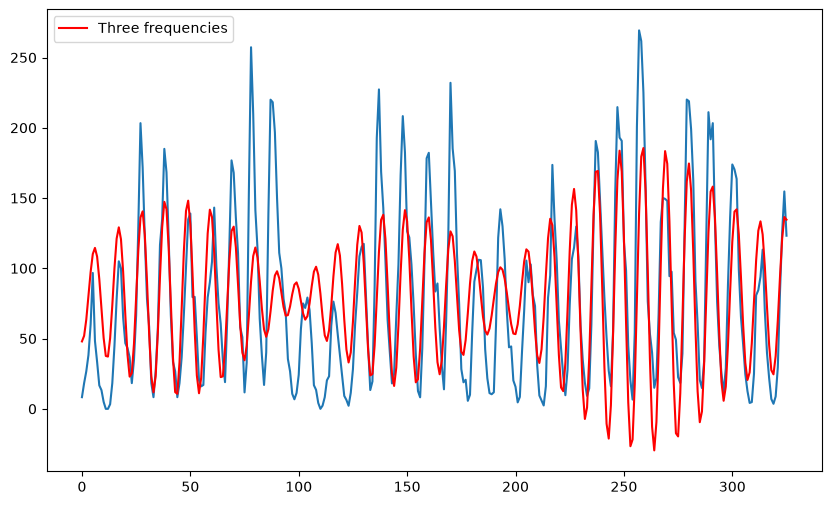

In [116]:
n = len(y)
f = f_opt_3 #f_opt was obtained from the grid minimization
x = np.arange(1, n+1)
X = np.column_stack([np.ones(n)])
x = np.arange(1, n+1)
if np.isscalar(f):
    f = [f]
for j in range(len(f)):
    f1 = f[j]
    xcos = np.cos(2 * np.pi * f1 * x)
    xsin = np.sin(2 * np.pi * f1 * x)
    X = np.column_stack([X, xcos, xsin])

md_3 = sm.OLS(y, X).fit()
print(md_3.summary())
best_rss_3 = np.sum(md_3.resid ** 2)
print(best_rss_3)


plt.figure(figsize = (10, 6))
#plt.plot(y, linestyle = '', marker = '')
plt.plot(y)
#plt.plot(md_1.fittedvalues, color = 'red', label = 'One frequency')
#plt.plot(md_2.fittedvalues, color = 'black', label = 'Two frequencies')
plt.plot(md_3.fittedvalues, color = 'red', label = 'Three frequencies')
plt.legend()
plt.show()

Below we look at the smallest RSS achieved with one frequency, two frequencies and three frequencies respectively. 

In [117]:
print(np.array([best_rss_1, best_rss_2, best_rss_3]))

[866099.36939274 702659.81490815 580371.71262496]


If, instead of trying to find the best frequencies, we only look at the Fourier frequencies, the RSS will be much higher. 

The best Fourier frequencies can be found as follows (these are the maximizers of the periodogram): 

In [118]:
print(n * freqs[np.argsort(pgram)[::-1]])
print(rss([30/n, 31/n, 3/n]))

[ 30.  31.   3.  32.  29.  33.  27.   6.  40.  28.   2.  25.   5.   4.
  39.  37.  15.  57.  35.  38.   1.  26.   8.  12.  22.  34.  23.  44.
  60.  59.  10.   9.  62.  55.   7.  19.  11.  68.  45.  14.  20.  21.
  43.  17.  65.  49.  24.  41.  64.  54.  47.  67.  71.  56. 102.  77.
  46.  82.  89.  90.  52.  76.  18.  80. 116.  58.  95.  16. 141. 100.
  73.  42.  63.  70.  66. 101.  78.  75.  87. 105.  84.  99. 115. 154.
  91.  61.  69. 117. 112. 160. 146.  93.  13. 153. 120.  53.  79. 156.
 132.  74. 138. 142. 137. 139.  48. 124.  51. 150. 135. 152. 104. 131.
 147. 148.  83. 159. 158. 118.  50. 130. 161. 128.  36. 129. 125. 111.
  85. 106.  94. 140. 119. 123. 143.  98.  92. 162. 110. 107. 113. 122.
 151. 114. 144.  97.  72.  86. 126. 134. 127. 155. 157. 133.  81. 145.
 149. 103.  88. 108. 136.  96. 121. 109.]
727514.7507267644


In [119]:
print(rss([30/n, 31/n, 3/n, 32/n, 29/n]))
print(rss(f_opt_3))
print([30/n, 31/n, 3/n, 32/n, 29/n])
print(f_opt_3)

563413.645247653
580371.7126249631
[0.09202453987730061, 0.0950920245398773, 0.009202453987730062, 0.09815950920245399, 0.08895705521472393]
[0.09120603 0.09346734 0.10025126]


Below we plot the best fitted function with the top 5 Fourier frequencies. 

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     38.17
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.28e-48
Time:                        19:49:48   Log-Likelihood:                -1677.7
No. Observations:                 326   AIC:                             3377.
Df Residuals:                     315   BIC:                             3419.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         78.8963      2.342     33.683      0.0

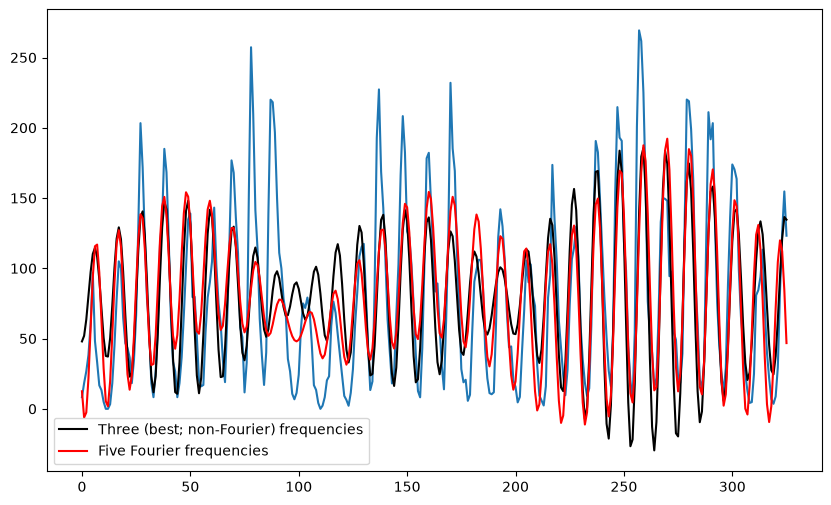

In [120]:
n = len(y)
f = [30/n, 31/n, 3/n, 32/n, 29/n]
x = np.arange(1, n+1)
X = np.column_stack([np.ones(n)])
x = np.arange(1, n+1)
if np.isscalar(f):
    f = [f]
for j in range(len(f)):
    f1 = f[j]
    xcos = np.cos(2 * np.pi * f1 * x)
    xsin = np.sin(2 * np.pi * f1 * x)
    X = np.column_stack([X, xcos, xsin])

md_5 = sm.OLS(y, X).fit()
print(md_5.summary())
best_rss_5 = np.sum(md_3.resid ** 2)
print(best_rss_5) #computed with Fourier frequencies


plt.figure(figsize = (10, 6))
#plt.plot(y, linestyle = '', marker = '')
plt.plot(y)
#plt.plot(md_1.fittedvalues, color = 'red', label = 'One frequency')
plt.plot(md_3.fittedvalues, color = 'black', label = 'Three (best; non-Fourier) frequencies')
plt.plot(md_5.fittedvalues, color = 'red', label = 'Five Fourier frequencies')
plt.legend()
plt.show()

Below we compare the prediction accuracy for the best models based on Fourier frequencies (compared to the frequencies chosen over grids). We use the first $n - 50$ observations for training the model, and check the prediction accuracy on the test dataset (last 50 observations). 

Five Fourier frequencies:       1648.24
Three frequencies (f_opt_3):  1236.05
Two frequencies (f_opt_2):    2751.11
Three Fourier frequencies:    2628.22


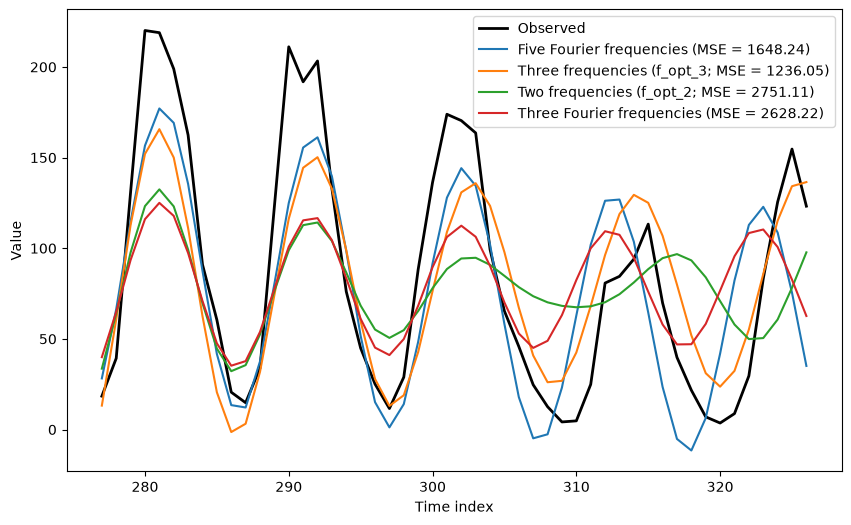

In [121]:
n = len(y)
n_test = 50
x = np.arange(1, n + 1, dtype=float)

def compute_test_mse(f):
    f = np.asarray(f, dtype=float)
    cos_cols = np.cos(2 * np.pi * np.outer(x, f))
    sin_cols = np.sin(2 * np.pi * np.outer(x, f))
    X_all = np.column_stack([np.ones(n), cos_cols, sin_cols])

    model = sm.OLS(y[:-n_test], X_all[:-n_test]).fit()
    y_pred_test = model.predict(X_all[-n_test:])
    test_mse = np.mean((y[-n_test:] - y_pred_test) ** 2)
    return test_mse, y_pred_test

test_mse_5, pred_5 = compute_test_mse([30/n, 31/n, 29/n, 32/n, 3/n])
test_mse_opt_3, pred_opt_3 = compute_test_mse(f_opt_3)
test_mse_opt_2, pred_opt_2 = compute_test_mse(f_opt_2)
test_mse_3, pred_3 = compute_test_mse([30/n, 31/n, 29/n])

print(f"Five Fourier frequencies:       {test_mse_5:.6g}")
print(f"Three frequencies (f_opt_3):  {test_mse_opt_3:.6g}")
print(f"Two frequencies (f_opt_2):    {test_mse_opt_2:.6g}")
print(f"Three Fourier frequencies:    {test_mse_3:.6g}")

# Show only the last 50 observations and their predictions
x_test = x[-n_test:]

plt.figure(figsize=(10, 6))
plt.plot(x_test, y[-n_test:], color="black", linewidth=2, label="Observed")
plt.plot(x_test, pred_5,
         label=f"Five Fourier frequencies (MSE = {test_mse_5:.6g})")
plt.plot(x_test, pred_opt_3,
         label=f"Three frequencies (f_opt_3; MSE = {test_mse_opt_3:.6g})")
plt.plot(x_test, pred_opt_2,
         label=f"Two frequencies (f_opt_2; MSE = {test_mse_opt_2:.6g})")
plt.plot(x_test, pred_3,
         label=f"Three Fourier frequencies (MSE = {test_mse_3:.6g})")
plt.xlabel("Time index")
plt.ylabel("Value")
plt.legend()
plt.show()

## Audio Dataset



Consider the audio dataset that we have used in the past couple of lectures. We add a small amount of noise to the actual piano note. 

In [122]:
import librosa
yorig,sr=librosa.load("Hear Piano Note - Middle C.mp3")
sig_noise = 0.1
y = yorig + sig_noise*np.random.randn(len(yorig)) #adding noise to the audio signal
n = len(y)
print(n)
print(sr)
print(n/sr)

301272
22050
13.66312925170068


In [123]:
from IPython.display import Audio, display
display(Audio(y, rate=sr))

The following function computes the periodogram of this dataset. 

In [124]:
def periodogram(y):
    fft_y = np.fft.fft(y) #this computation is very fast O(n log n)
    n = len(y)
    fourier_freqs = np.arange(1/n, 1/2, 1/n)
    m = len(fourier_freqs)
    pgram_y = (np.abs(fft_y[1:m+1]) ** 2)/n
    return fourier_freqs, pgram_y


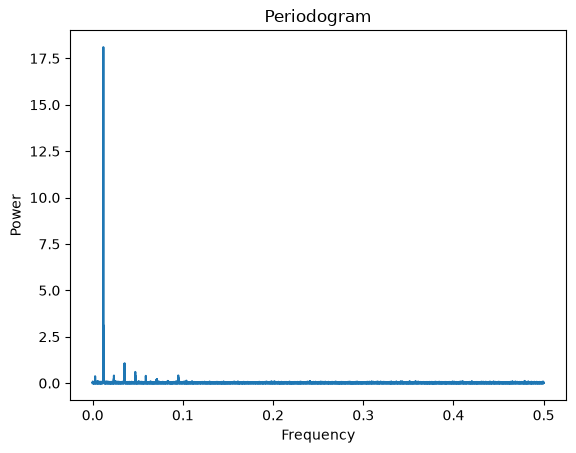

In [125]:
freqs, pgram = periodogram(y)
plt.plot(freqs, pgram)
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

Below we identify the top 10 frequencies having high periodogram values. Then fit the linear model with sines and cosines at those frequencies. 

In [126]:
freqs, pgram = periodogram(y)

k = 10
top_idx = np.argsort(pgram)[-k:][::-1]
f = freqs[top_idx]
print(f"Top {k} frequencies:", f)

n = len(y)
x = np.arange(1, n + 1)
X = np.ones((n, 1))

for f1 in f:
    X = np.column_stack([
        X,
        np.cos(2 * np.pi * f1 * x),
        np.sin(2 * np.pi * f1 * x)
    ])

md_k = sm.OLS(y, X).fit()


Top 10 frequencies: [0.01179997 0.01177341 0.01180329 0.01172694 0.01179665 0.01180661
 0.01177009 0.01177673 0.01180993 0.01172363]


Below we plot the fitted values corresponding to the linear model. 

In [127]:
fitted_sinusoid = md_k.fittedvalues

display(Audio(fitted_sinusoid, rate=sr))
display(Audio(y, rate=sr))
display(Audio(yorig, rate=sr))

The fitted sound seems noiseless but also quite different from the original sound. Below we repeat the exercise with a much larger value of $k$. The code below again computes the fitted values for the linear model corresponding to the top $k$ sinusoids, but the code does not directly fit the linear model but instead uses inbuilt functions from the fft library for efficient computation. 

In [128]:
Y = np.fft.fft(y)
n = len(y)

# Choose k positive frequencies
k = 10000
top_idx = np.argsort(np.abs(Y[1:n//2])**2)[-k:] + 1

Y_fit = np.zeros_like(Y)
Y_fit[0] = Y[0]
Y_fit[top_idx] = Y[top_idx]
Y_fit[-top_idx] = Y[-top_idx]  # Matching negative frequencies

fitted_audio = np.fft.ifft(Y_fit).real

Now the fitted sound is affected by noise. This is the classic bias-variance tradeoff. When $k$ is chosen small, the fitted sound is noiseless but is biased (i.e., far in nature from the original sound) but when $k$ is chosen large, the fitted sound resembles the original sound but is affected by noise. 

In [129]:
display(Audio(fitted_audio, rate=sr))
display(Audio(y, rate=sr))
display(Audio(yorig, rate=sr))